# 0. Imports

In [1]:
import numbers
from tqdm import tqdm
from itertools import islice

import pandas as pd
import numpy as np

from river import (
    compose,
    preprocessing,
    tree,
    linear_model,
    forest,
    metrics,
    stream,
    stats,
    feature_extraction
)
from itertools import islice

import matplotlib.pyplot as plt

En River, el holdout se simula acumulando los primeros 70% de instancias para entrenamiento y el 30% restante para test.

# 1. Preparación offline

Vamos a trabajar sobre el dataset de weatherAUS ([link al dataset](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)). Consiste en predecir si mañana lloverá o no a partir de una serie de datos. Cuenta con 10 años de registros de datos.

In [2]:
df = pd.read_csv('data/weatherAUS.csv')

In [3]:
print(df.shape)
print(df.dtypes)
print(df['RainTomorrow'].value_counts(normalize=True))

(145460, 23)
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object
RainTomorrow
No     0.775819
Yes    0.224181
Name: proportion, dtype: float64


In [4]:
print(df.isna().sum()/df.shape[0])

Date             0.000000
Location         0.000000
MinTemp          0.010209
MaxTemp          0.008669
Rainfall         0.022419
Evaporation      0.431665
Sunshine         0.480098
WindGustDir      0.070989
WindGustSpeed    0.070555
WindDir9am       0.072639
WindDir3pm       0.029066
WindSpeed9am     0.012148
WindSpeed3pm     0.021050
Humidity9am      0.018246
Humidity3pm      0.030984
Pressure9am      0.103568
Pressure3pm      0.103314
Cloud9am         0.384216
Cloud3pm         0.408071
Temp9am          0.012148
Temp3pm          0.024811
RainToday        0.022419
RainTomorrow     0.022460
dtype: float64


El dataset consta de valores nulos, incluso en la variable objetivo. Las filas con nulos en la variable objetivo se descartan. también se van a descartar las variables con un 40% de nulos. El resto de los datos serán tratados dentro del proceso online.

In [5]:
cols_to_drop = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

In [6]:
# Eliminamos las filas sin target:
df.drop(columns=cols_to_drop, inplace=True)

df = df.dropna(subset=['RainTomorrow', 'RainToday'])

df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [ ]:
# Separamos las características (X) de la etiqueta (y)
X = df.drop(columns=['Date', 'RainTomorrow'])
y = df['RainTomorrow']


n_samples = len(df)

Con todo el dataset listo y el datastream preparado, ya podemos hacer la predicción online que se pide. En el pipeline de entrenamiento es donde se van a tratar los datos, ya que en la vida real no llegan datos limpios.

# Ejericio 1: Entrenamiento con holdout

Para el pipeline tenemos que separar las columnas en categóricas y numéricas ya que van a tener tratamientos distintos. 
En el pipeline se va a hacer una imputación de missings (por media en numéricas y moda en categóricas), después un escalado en numéricas y un OHE en categóricas. Además, para la variables de `Location` al tener muchos valores únicos se va a hacer un TargetEncoding.

In [8]:
train_size = int(n_samples * 0.70)

In [9]:
columnas_numericas = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 
    'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday'
]

columnas_categoricas = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

In [10]:
# Creamos los imputadores pasándoles las tuplas generadas dinámicamente
# River recibirá: ('MinTemp', Mean()), ('MaxTemp', Mean()), etc.
imputador_num = preprocessing.StatImputer(*[(col, stats.Mean()) for col in columnas_numericas])
imputador_cat = preprocessing.StatImputer(*[(col, stats.Mode()) for col in columnas_categoricas])



# CONSTRUCCIÓN DE LAS RAMAS DEL PIPELINE


# RAMA 1: Location (Extraemos la probabilidad de lluvia de cada ciudad)
rama_location = feature_extraction.TargetAgg(
    by='Location',
    # how=stats.BayesianMean(prior=0.5, prior_weight=10)
    how=stats.Mean()
)

# RAMA 2: Resto de Categóricas (Filtramos -> Imputamos Nulos -> One-Hot)
rama_categorica = (
    compose.Select(*columnas_categoricas) | 
    imputador_cat | 
    preprocessing.OneHotEncoder()
)

# RAMA 3: Numéricas (Filtramos -> Imputamos Nulos -> Escalamos)
rama_numerica = (
    compose.Select(*columnas_numericas) | 
    imputador_num | 
    preprocessing.StandardScaler()
)


# PIPELINE FINAL

preprocesamiento = rama_location + rama_categorica + rama_numerica

In [31]:
def build_preprocesamiento():
    imputador_num = preprocessing.StatImputer(*[(col, stats.Mean()) for col in columnas_numericas])
    imputador_cat = preprocessing.StatImputer(*[(col, stats.Mode()) for col in columnas_categoricas])
    rama_location  = feature_extraction.TargetAgg(by='Location', how=stats.Mean())
    rama_categorica = compose.Select(*columnas_categoricas) | imputador_cat | preprocessing.OneHotEncoder()
    rama_numerica   = compose.Select(*columnas_numericas)   | imputador_num | preprocessing.StandardScaler()
    return rama_location + rama_categorica + rama_numerica

In [32]:
## Los modelos 

modelo_1 = build_preprocesamiento() | tree.HoeffdingAdaptiveTreeClassifier(
    grace_period=100,
    delta=1e-5,
    leaf_prediction='nb',   # Naive Bayes en hojas: mejor con desbalance
    seed=42
)
modelo_2 = build_preprocesamiento() | forest.ARFClassifier(
    n_models=25,        
    lambda_value=6,     
    grace_period=50,   
    seed=42
)

In [33]:
dataset_stream = stream.iter_pandas(X, y)

In [ ]:
## Entrenamiento

for i, (x_i, y_i) in enumerate(
        tqdm(islice(dataset_stream, train_size), total=train_size)
    ):
    modelo_1.learn_one(x_i, y_i)
    modelo_2.learn_one(x_i, y_i)

  3%|▎         | 3366/98550 [00:16<08:23, 189.00it/s]

In [24]:
def inicializar_metricas():
    return {
        'Accuracy': metrics.Accuracy(),
        'Balanced_Accuracy': metrics.BalancedAccuracy(),
        'Kappa': metrics.CohenKappa(),
        'F1': metrics.F1(),
        'RocAuc': metrics.ROCAUC(),
        'Confusion_Matrix': metrics.ConfusionMatrix(),
        'Reporte_Completo': metrics.ClassificationReport() # Calcula Precision, Recall y F1 por clase
    }

metricas_m1 = inicializar_metricas()
metricas_m2 = inicializar_metricas()

# Estructuras para guardar los datos de las gráficas
historial_graficas = {
    'instancia': [],
    'm1_accuracy': [], 'm1_kappa': [], 'm1_f1': [], 'm1_rocauc': [],
    'm2_accuracy': [], 'm2_kappa': [], 'm2_f1': [], 'm2_rocauc': []
}

In [ ]:
test_size = n_samples - train_size

for i, (x_i, y_i) in enumerate(
        tqdm(islice(dataset_stream, test_size), total=test_size)
    ):
    
    # 1. Realizar predicciones
    y_pred_1 = modelo_1.predict_one(x_i)
    y_pred_2 = modelo_2.predict_one(x_i)
    
    y_pred_proba_1 = modelo_1.predict_proba_one(x_i)
    y_pred_proba_2 = modelo_2.predict_proba_one(x_i)
    
    # 2. Actualizar las métricas (si la predicción no es nula, lo cual pasa al inicio pero aquí ya están entrenados)
    if y_pred_1 is not None:
        metricas_m1['Accuracy'].update(y_i, y_pred_1)
        metricas_m1['Balanced_Accuracy'].update(y_i, y_pred_1)
        metricas_m1['Kappa'].update(y_i, y_pred_1)
        metricas_m1['Reporte_Completo'].update(y_i, y_pred_1)
        metricas_m1['F1'].update(y_i, y_pred_1)
        metricas_m1['RocAuc'].update(y_i, y_pred_proba_1)
        metricas_m1['Confusion_Matrix'].update(y_true, y_pred_class_1)
        
    if y_pred_2 is not None:
        metricas_m2['Accuracy'].update(y_i, y_pred_2)
        metricas_m2['Balanced_Accuracy'].update(y_i, y_pred_2)
        metricas_m2['Kappa'].update(y_i, y_pred_2)
        metricas_m2['Reporte_Completo'].update(y_i, y_pred_2)
        metricas_m2['F1'].update(y_i, y_pred_2)
        metricas_m2['RocAuc'].update(y_i, y_pred_proba_2)
        metricas_m2['Confusion_Matrix'].update(y_true, y_pred_class_2)

    # 3. Guardar datos para gráficas (cada 500 iteraciones para no saturar la memoria ni el gráfico)
    if (i + 1) % 500 == 0:
        historial_graficas['instancia'].append(i + 1)
        historial_graficas['m1_accuracy'].append(metricas_m1['Accuracy'].get())
        historial_graficas['m1_kappa'].append(metricas_m1['Kappa'].get())
        historial_graficas['m1_f1'].append(metricas_m1['F1'].get())
        historial_graficas['m1_rocauc'].append(metricas_m1['RocAuc'].get())
        historial_graficas['m2_accuracy'].append(metricas_m2['Accuracy'].get())
        historial_graficas['m2_kappa'].append(metricas_m2['Kappa'].get())
        historial_graficas['m2_f1'].append(metricas_m2['F1'].get())
        historial_graficas['m2_rocauc'].append(metricas_m2['RocAuc'].get())

100%|██████████| 42237/42237 [00:42<00:00, 995.36it/s] 


In [ ]:
# --- IMPRESIÓN DE RESULTADOS ---
for nombre, metricas in [("MODELO 1 (HOEFFDING TREE)", metricas_m1), ("MODELO 2 (ADAPTIVE RANDOM FOREST)", metricas_m2)]:
    print(f"\n=== RESULTADOS {nombre} ===")
    print(f"Accuracy: {metricas['Accuracy'].get():.4f}")
    print(f"ROC AUC:  {metricas['RocAuc'].get():.4f}")
    print(f"Kappa:    {metricas['Kappa'].get():.4f}")
    print("\nMatriz de Confusión:\n", metricas['Confusion_Matrix'])
    print("\nReporte por clases:\n", metricas['Reporte_Completo'])
    print("-" * 50)



=== RESULTADOS MODELO 1 (HOEFFDING TREE) ===
Accuracy: 0.7816
ROC AUC:  -0.0000
Kappa:    0.0000

Reporte por clases:
            Precision   Recall    F1       Support  
                                                   
       0      78.16%   100.00%   87.74%     33014  
       1       0.00%     0.00%    0.00%      9223  
                                                   
   Macro      39.08%    50.00%   43.87%            
   Micro      78.16%    78.16%   78.16%            
Weighted      61.10%    78.16%   68.58%            

                  78.16% accuracy                  
--------------------------------------------------

=== RESULTADOS MODELO 2 (ADAPTIVE RANDOM FOREST) ===
Accuracy: 0.6157
ROC AUC:  0.5016
Kappa:    -0.0011

Reporte por clases:
            Precision   Recall   F1       Support  
                                                  
       0      78.13%   70.60%   74.17%     33014  
       1      21.76%   29.27%   24.97%      9223  
                            

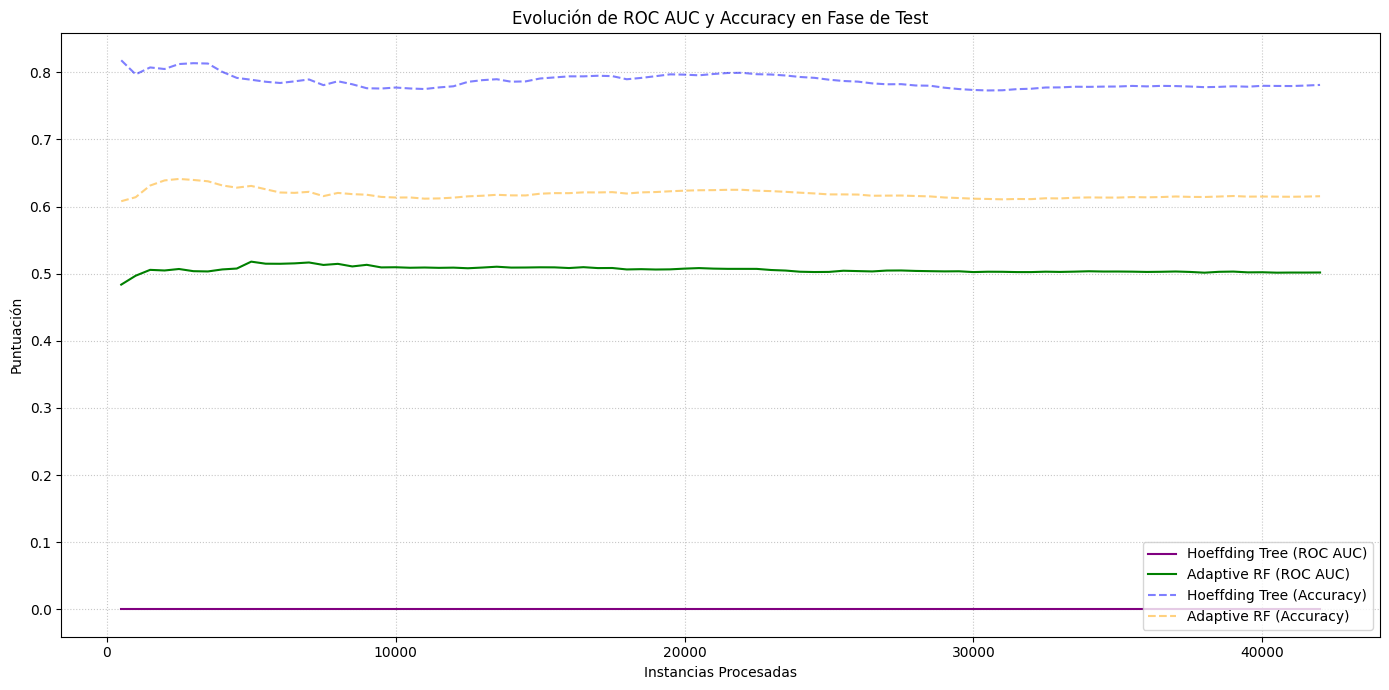

In [29]:
df_graficas = pd.DataFrame(historial_graficas)
plt.figure(figsize=(14, 7))

# Graficamos el ROC AUC
plt.plot(df_graficas['instancia'], df_graficas['m1_rocauc'], label='Hoeffding Tree (ROC AUC)', linestyle='-', color='purple')
plt.plot(df_graficas['instancia'], df_graficas['m2_rocauc'], label='Adaptive RF (ROC AUC)', linestyle='-', color='green')

# Graficamos el Accuracy (con transparencia para que no sature)
plt.plot(df_graficas['instancia'], df_graficas['m1_accuracy'], label='Hoeffding Tree (Accuracy)', linestyle='--', color='blue', alpha=0.5)
plt.plot(df_graficas['instancia'], df_graficas['m2_accuracy'], label='Adaptive RF (Accuracy)', linestyle='--', color='orange', alpha=0.5)

plt.title('Evolución de ROC AUC y Accuracy en Fase de Test')
plt.xlabel('Instancias Procesadas')
plt.ylabel('Puntuación')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

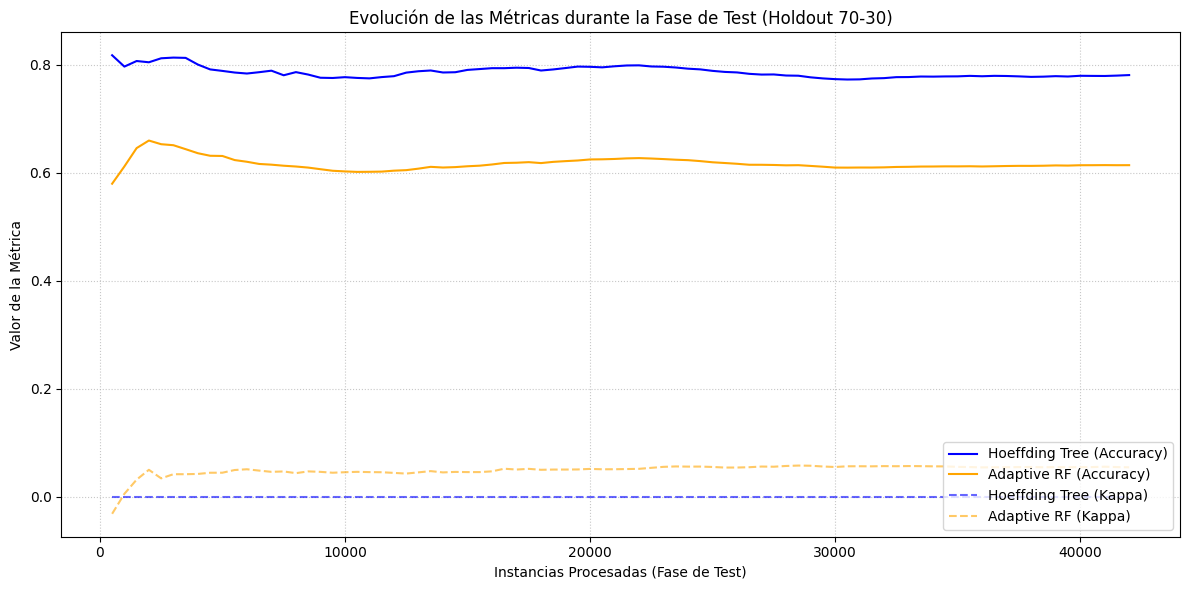

In [18]:
# Convertimos el diccionario a un DataFrame para graficar fácilmente
df_graficas = pd.DataFrame(historial_graficas)

plt.figure(figsize=(12, 6))

# Graficamos el Accuracy
plt.plot(df_graficas['instancia'], df_graficas['m1_accuracy'], label='Hoeffding Tree (Accuracy)', linestyle='-', color='blue')
plt.plot(df_graficas['instancia'], df_graficas['m2_accuracy'], label='Adaptive RF (Accuracy)', linestyle='-', color='orange')

# Graficamos el Índice Kappa (Suele ser más bajo, pero es más realista)
plt.plot(df_graficas['instancia'], df_graficas['m1_kappa'], label='Hoeffding Tree (Kappa)', linestyle='--', color='blue', alpha=0.6)
plt.plot(df_graficas['instancia'], df_graficas['m2_kappa'], label='Adaptive RF (Kappa)', linestyle='--', color='orange', alpha=0.6)

plt.title('Evolución de las Métricas durante la Fase de Test (Holdout 70-30)')
plt.xlabel('Instancias Procesadas (Fase de Test)')
plt.ylabel('Valor de la Métrica')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

In [ ]:
# 1. Carga de datos y división Holdout (70% Train, 30% Test)
dataset = datasets.CreditCard()
total_samples = dataset.n_samples
train_limit = int(total_samples * 0.70)

# 2. Modelos y Preprocesamiento
# El ARF es un ensamble de árboles, no necesita escalar los datos numéricos
modelo_arf = forest.ARFClassifier(n_models=10, seed=42)

# La Regresión Logística SÍ necesita preprocesamiento. 
# Usamos el operador '|' para crear la tubería (Pipeline) de escalado dinámico.
modelo_lr = preprocessing.StandardScaler() | linear_model.LogisticRegression()

# 3. Inicializamos las métricas POR SEPARADO (Solución al error)
auc_arf = metrics.ROCAUC()
f1_arf = metrics.F1()

auc_lr = metrics.ROCAUC()
f1_lr = metrics.F1()

# Listas para guardar la evolución y graficar luego
evolucion_auc_arf = []
evolucion_auc_lr = []
pasos = []

print("Entrenando modelos (70% de los datos)... esto puede tardar unos minutos.")

# 4. Bucle principal de Data Streams
for i, (x, y) in enumerate(dataset):
    
    # --- FASE DE ENTRENAMIENTO ---
    if i < train_limit:
        modelo_arf.learn_one(x, y)
        modelo_lr.learn_one(x, y)
        
    # --- FASE DE TEST (Evaluación Holdout) ---
    else:
        # Extraemos predicciones (probabilidad y clase)
        pred_prob_arf = modelo_arf.predict_proba_one(x)
        pred_clase_arf = modelo_arf.predict_one(x)
        
        pred_prob_lr = modelo_lr.predict_proba_one(x)
        pred_clase_lr = modelo_lr.predict_one(x)
        
        # Para el ROC AUC necesitamos la probabilidad de la clase 1 (Fraude)
        # Usamos .get(1, 0) por si el diccionario de probabilidades viene vacío al principio
        prob_fraude_arf = pred_prob_arf.get(1, 0) if pred_prob_arf else 0
        prob_fraude_lr = pred_prob_lr.get(1, 0) if pred_prob_lr else 0
        
        # Actualizamos las métricas individualmente
        auc_arf.update(y, prob_fraude_arf)
        f1_arf.update(y, pred_clase_arf)
        
        auc_lr.update(y, prob_fraude_lr)
        f1_lr.update(y, pred_clase_lr)

        # Guardamos datos cada 1000 iteraciones para la gráfica del PDF
        if i % 1000 == 0:
            evolucion_auc_arf.append(auc_arf.get())
            evolucion_auc_lr.append(auc_lr.get())
            pasos.append(i)



Entrenando modelos (70% de los datos)... esto puede tardar unos minutos.



--- RESULTADOS FINALES HOLDOUT (30% TEST) ---
Adaptive Random Forest -> ROC AUC: 0.8101 | F1: 0.2720
Logistic Regression    -> ROC AUC: 0.8240 | F1: 0.7345


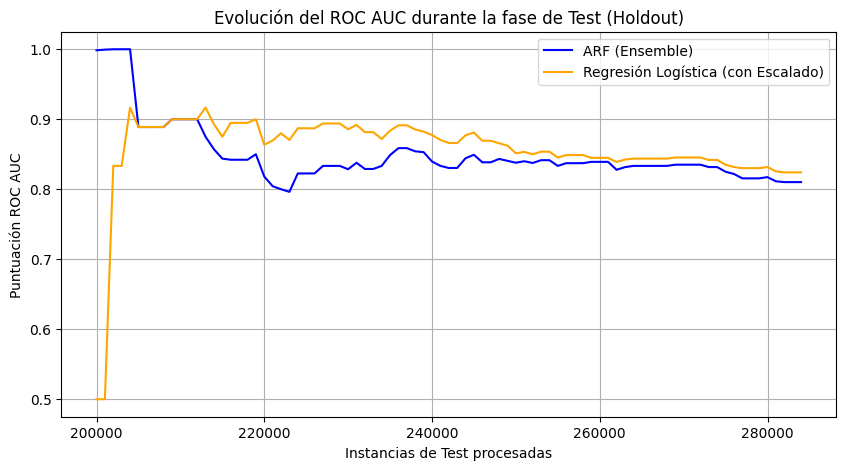

In [4]:
print("\n--- RESULTADOS FINALES HOLDOUT (30% TEST) ---")
print(f"Adaptive Random Forest -> ROC AUC: {auc_arf.get():.4f} | F1: {f1_arf.get():.4f}")
print(f"Logistic Regression    -> ROC AUC: {auc_lr.get():.4f} | F1: {f1_lr.get():.4f}")

# 5. Generar Gráfica para el Documento
plt.figure(figsize=(10, 5))
plt.plot(pasos, evolucion_auc_arf, label='ARF (Ensemble)', color='blue')
plt.plot(pasos, evolucion_auc_lr, label='Regresión Logística (con Escalado)', color='orange')
plt.title('Evolución del ROC AUC durante la fase de Test (Holdout)')
plt.xlabel('Instancias de Test procesadas')
plt.ylabel('Puntuación ROC AUC')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from river import imblearn
from river import preprocessing
from river import linear_model

# Creamos una tubería con DOS pasos de preprocesamiento antes del modelo
pipeline_experta = (
    imblearn.RandomUnderSampler(target_proportion={0: 0.5, 1: 0.5}, seed=42) | # 1. Preprocesamiento: Equilibra las clases 50/50
    preprocessing.StandardScaler() |                                           # 2. Preprocesamiento: Escala las variables numéricas
    linear_model.LogisticRegression()                                          # 3. Modelo
)

Entrenando modelos (70% de los datos)...

=== RESULTADOS FINALES HOLDOUT (30% TEST) ===

--- MODELO 1: REGRESIÓN LOGÍSTICA BASE ---
ROC AUC   : 0.9926
F1-Score  : 0.9926
Precision : 1.0000
Recall    : 0.9853
Matriz de Confusión:
    0         1    
0   170,046     0  
1         3   201  

--------------------------------------------------

--- MODELO 2: PIPELINE EXPERTA (Undersampling) ---
ROC AUC   : 0.9926
F1-Score  : 0.9640
Precision : 0.9437
Recall    : 0.9853
Matriz de Confusión:
    0         1    
0   170,034    12  
1         3   201  



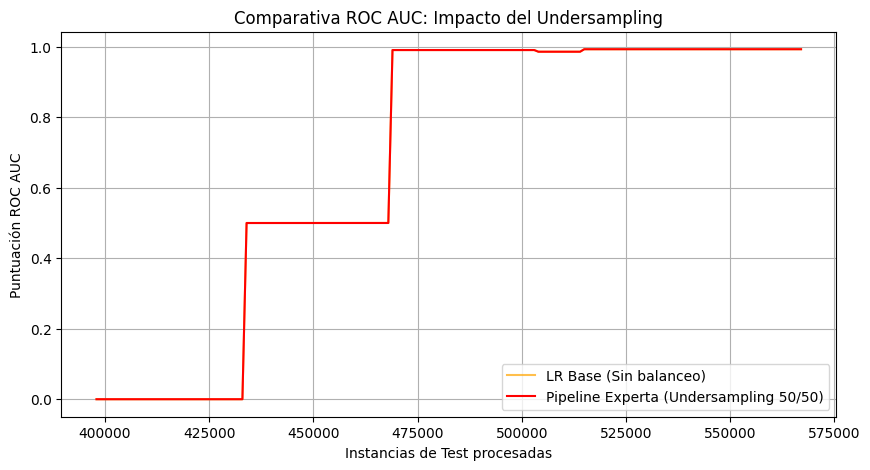

In [23]:
from river import datasets
from river import imblearn
from river import linear_model
from river import preprocessing
from river import metrics
import matplotlib.pyplot as plt

# 1. Carga de datos y división Holdout
dataset = datasets.HTTP()
total_samples = dataset.n_samples
train_limit = int(total_samples * 0.70)

# 2. Modelos
# Modelo 1: Regresión Logística Estándar (Modelo Base)
modelo_lr_base = preprocessing.StandardScaler() | linear_model.LogisticRegression()

# Modelo 2: PIPELINE EXPERTA (Wrapper de Undersampling envolviendo la tubería)
pipeline_experta = imblearn.RandomUnderSampler(
    classifier=(preprocessing.StandardScaler() | linear_model.LogisticRegression()),
    desired_dist={0: 0.5, 1: 0.5},
    seed=42
)

# 3. Inicializamos TODAS las métricas para AMBOS modelos
# --- Métricas Modelo Base ---
auc_base = metrics.ROCAUC()
f1_base = metrics.F1()
matriz_confusion_base = metrics.ConfusionMatrix()
precision_base = metrics.Precision()
recall_base = metrics.Recall()

# --- Métricas Pipeline Experta ---
auc_exp = metrics.ROCAUC()
f1_exp = metrics.F1()
matriz_confusion_exp = metrics.ConfusionMatrix()
precision_exp = metrics.Precision()
recall_exp = metrics.Recall()

# Listas para guardar la evolución del AUC
evolucion_auc_base = []
evolucion_auc_exp = []
pasos = []

print("Entrenando modelos (70% de los datos)...")

# 4. Bucle principal de Data Streams
for i, (x, y) in enumerate(dataset):
    
    # --- FASE DE ENTRENAMIENTO ---
    if i < train_limit:
        modelo_lr_base.learn_one(x, y)
        pipeline_experta.learn_one(x, y)
        
    # --- FASE DE TEST (Evaluación Holdout) ---
    else:
        # Extraemos predicciones
        pred_prob_base = modelo_lr_base.predict_proba_one(x)
        pred_clase_base = modelo_lr_base.predict_one(x)
        
        pred_prob_exp = pipeline_experta.predict_proba_one(x)
        pred_clase_exp = pipeline_experta.predict_one(x)
        
        # Probabilidades de la clase 1 (Fraude)
        prob_fraude_base = pred_prob_base.get(1, 0) if pred_prob_base else 0
        prob_fraude_exp = pred_prob_exp.get(1, 0) if pred_prob_exp else 0
        
        # --- Actualizamos métricas Modelo Base ---
        auc_base.update(y, prob_fraude_base)
        f1_base.update(y, pred_clase_base)
        matriz_confusion_base.update(y, pred_clase_base)
        precision_base.update(y, pred_clase_base)
        recall_base.update(y, pred_clase_base)
        
        # --- Actualizamos métricas Pipeline Experta ---
        auc_exp.update(y, prob_fraude_exp)
        f1_exp.update(y, pred_clase_exp)
        matriz_confusion_exp.update(y, pred_clase_exp)
        precision_exp.update(y, pred_clase_exp)
        recall_exp.update(y, pred_clase_exp)

        # Guardamos datos cada 1000 iteraciones para la gráfica
        if i % 1000 == 0:
            evolucion_auc_base.append(auc_base.get())
            evolucion_auc_exp.append(auc_exp.get())
            pasos.append(i)

# 5. Imprimir Resultados Finales Comparativos
print("\n" + "="*50)
print("=== RESULTADOS FINALES HOLDOUT (30% TEST) ===")
print("="*50)

print("\n--- MODELO 1: REGRESIÓN LOGÍSTICA BASE ---")
print(f"ROC AUC   : {auc_base.get():.4f}")
print(f"F1-Score  : {f1_base.get():.4f}")
print(f"Precision : {precision_base.get():.4f}")
print(f"Recall    : {recall_base.get():.4f}")
print("Matriz de Confusión:")
print(matriz_confusion_base)

print("\n" + "-"*50)

print("\n--- MODELO 2: PIPELINE EXPERTA (Undersampling) ---")
print(f"ROC AUC   : {auc_exp.get():.4f}")
print(f"F1-Score  : {f1_exp.get():.4f}")
print(f"Precision : {precision_exp.get():.4f}")
print(f"Recall    : {recall_exp.get():.4f}")
print("Matriz de Confusión:")
print(matriz_confusion_exp)

print("\n" + "="*50)

# 6. Generar Gráfica para el Documento
plt.figure(figsize=(10, 5))
plt.plot(pasos, evolucion_auc_base, label='LR Base (Sin balanceo)', color='orange', alpha=0.7)
plt.plot(pasos, evolucion_auc_exp, label='Pipeline Experta (Undersampling 50/50)', color='red')
plt.title('Comparativa ROC AUC: Impacto del Undersampling')
plt.xlabel('Instancias de Test procesadas')
plt.ylabel('Puntuación ROC AUC')
plt.legend()
plt.grid(True)
plt.show()

Iniciando Evaluación Prequential (Test-Then-Train) sobre los 284,807 registros...
Esto tomará unos minutos. Mostrando progreso:

[50000/567498] instancias procesadas...
[100000/567498] instancias procesadas...
[150000/567498] instancias procesadas...
[200000/567498] instancias procesadas...
[250000/567498] instancias procesadas...
[300000/567498] instancias procesadas...
[350000/567498] instancias procesadas...
[400000/567498] instancias procesadas...
[450000/567498] instancias procesadas...
[500000/567498] instancias procesadas...
[550000/567498] instancias procesadas...

--- RESULTADOS FINALES PREQUENTIAL (100% Dataset) ---
LR Estándar        -> ROC AUC: 0.9975 | F1: 0.9961
Pipeline Experta   -> ROC AUC: 0.9980 | F1: 0.9806


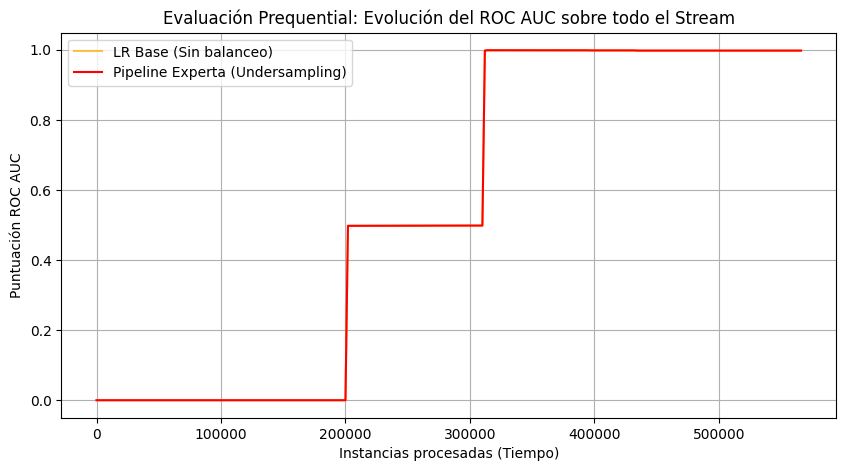

In [22]:
from river import datasets
from river import imblearn
from river import linear_model
from river import preprocessing
from river import metrics
import matplotlib.pyplot as plt

# 1. Carga de datos
dataset = datasets.HTTP()
n = dataset.n_samples
# 2. Inicializamos los Modelos (Igual que en el Ejercicio 1)
modelo_lr_base = preprocessing.StandardScaler() | linear_model.LogisticRegression()

pipeline_experta = imblearn.RandomUnderSampler(
    classifier=(preprocessing.StandardScaler() | linear_model.LogisticRegression()),
    desired_dist={0: 0.5, 1: 0.5},
    seed=42
)

# 3. Inicializamos las métricas INDIVIDUALMENTE para ambos modelos
auc_base = metrics.ROCAUC()
f1_base = metrics.F1()

auc_exp = metrics.ROCAUC()
f1_exp = metrics.F1()

evolucion_auc_base = []
evolucion_auc_exp = []
pasos = []

print("Iniciando Evaluación Prequential (Test-Then-Train) sobre los 284,807 registros...")
print("Esto tomará unos minutos. Mostrando progreso:\n")

# 4. Bucle principal Prequential
for i, (x, y) in enumerate(dataset):
    
    # --- PASO A: TEST (Predecir ANTES de aprender) ---
    pred_prob_base = modelo_lr_base.predict_proba_one(x)
    pred_clase_base = modelo_lr_base.predict_one(x)
    
    pred_prob_exp = pipeline_experta.predict_proba_one(x)
    pred_clase_exp = pipeline_experta.predict_one(x)
    
    prob_fraude_base = pred_prob_base.get(1, 0) if pred_prob_base else 0
    prob_fraude_exp = pred_prob_exp.get(1, 0) if pred_prob_exp else 0
    
    # Actualizamos las métricas con las predicciones a ciegas
    auc_base.update(y, prob_fraude_base)
    f1_base.update(y, pred_clase_base)
    
    auc_exp.update(y, prob_fraude_exp)
    f1_exp.update(y, pred_clase_exp)
    
    # --- PASO B: TRAIN (Aprender de la respuesta real) ---
    modelo_lr_base.learn_one(x, y)
    pipeline_experta.learn_one(x, y)

    # Guardamos datos cada 2000 iteraciones para la gráfica
    if i % 2000 == 0:
        evolucion_auc_base.append(auc_base.get())
        evolucion_auc_exp.append(auc_exp.get())
        pasos.append(i)
        
    # Imprimir progreso por pantalla
    if (i + 1) % 50000 == 0:
        print(f"[{i + 1}/{n}] instancias procesadas...")

print("\n" + "="*50)
print("--- RESULTADOS FINALES PREQUENTIAL (100% Dataset) ---")
print("="*50)
print(f"LR Estándar        -> ROC AUC: {auc_base.get():.4f} | F1: {f1_base.get():.4f}")
print(f"Pipeline Experta   -> ROC AUC: {auc_exp.get():.4f} | F1: {f1_exp.get():.4f}")

# 5. Generar Gráfica para el Documento
plt.figure(figsize=(10, 5))
plt.plot(pasos, evolucion_auc_base, label='LR Base (Sin balanceo)', color='orange', alpha=0.7)
plt.plot(pasos, evolucion_auc_exp, label='Pipeline Experta (Undersampling)', color='red')
plt.title('Evaluación Prequential: Evolución del ROC AUC sobre todo el Stream')
plt.xlabel('Instancias procesadas (Tiempo)')
plt.ylabel('Puntuación ROC AUC')
plt.legend()
plt.grid(True)
plt.show()

Monitoreando Elec2 en busca de Concept Drift...
Uncompressing into /home/jalcazar/river_data/HTTP
Total de derivas detectadas en Elec2: 8


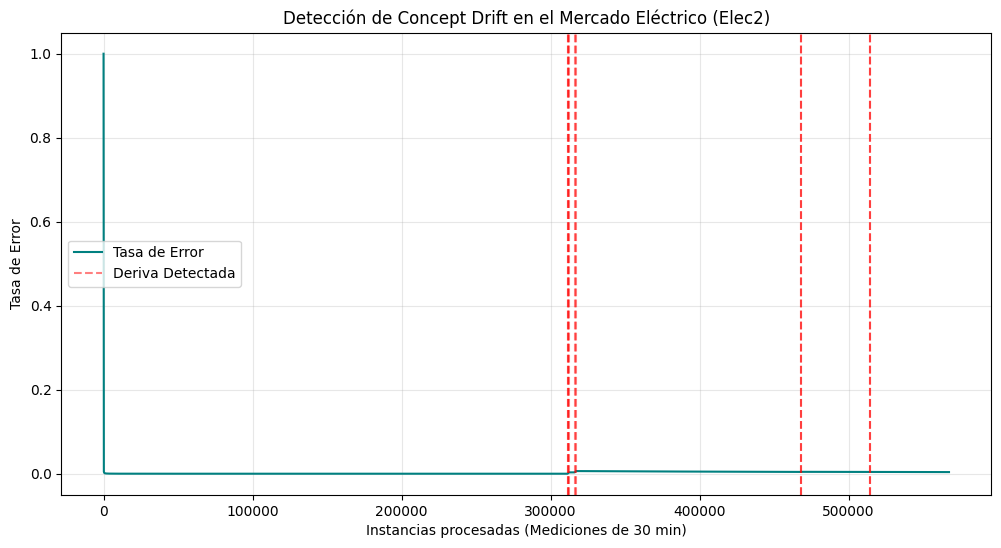

In [ ]:
from river import datasets
from river import drift
from river import tree
from river import metrics
import matplotlib.pyplot as plt

# 1. Cargamos el dataset
dataset = datasets.HTTP()

# Usamos un Árbol de Hoeffding (no requiere escalar datos y es rápido)
modelo = tree.HoeffdingTreeClassifier()

# 2. Inicializamos el Detector ADWIN
# Bajamos un poco la resolución (delta) para que sea más sensible a los cambios
detector_adwin = drift.ADWIN(delta=0.001)

metrica_acc = metrics.Accuracy()
evolucion_error = []
drifts_detectados = []
pasos = []

print("Monitoreando Elec2 en busca de Concept Drift...")

# 3. Bucle Prequential
for i, (x, y) in enumerate(dataset):
    
    # Predecir
    pred_clase = modelo.predict_one(x)
    
    # Evaluar error (0 acierto, 1 fallo)
    hubo_error = 0 if pred_clase == y else 1
    
    # Alimentar a ADWIN
    detector_adwin.update(hubo_error)
    
    # Comprobar Drift
    if detector_adwin.drift_detected:
        drifts_detectados.append(i)
        
    # Aprender y actualizar métricas
    modelo.learn_one(x, y)
    metrica_acc.update(y, pred_clase)
    
    if i % 200 == 0:  # Guardamos más a menudo porque es un dataset más pequeño
        evolucion_error.append(1.0 - metrica_acc.get())
        pasos.append(i)

print(f"Total de derivas detectadas en Elec2: {len(drifts_detectados)}")

# 4. Generar Gráfica
plt.figure(figsize=(12, 6))
plt.plot(pasos, evolucion_error, label='Tasa de Error', color='teal', linewidth=1.5)

for d in drifts_detectados:
    plt.axvline(x=d, color='red', linestyle='--', alpha=0.5)

if drifts_detectados:
    plt.axvline(x=drifts_detectados[0], color='red', linestyle='--', alpha=0.5, label='Deriva Detectada')

plt.title('Detección de Concept Drift en el Mercado Eléctrico (Elec2)')
plt.xlabel('Instancias procesadas (Mediciones de 30 min)')
plt.ylabel('Tasa de Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()